# What does a diffusion policy's uncertainty actually measure?

A minimal language-conditioned visuomotor policy (VLA) trained on **LIBERO-Goal**,
used to probe whether the dispersion between denoising samples is a usable
uncertainty signal.

**Pipeline**
1. Precompute frozen vision and language embeddings
2. Train a conditional DDPM over action chunks
3. **E1** — does language control the action? (positive + paraphrase control)
4. **E2** — does the policy notice when its inputs degrade?

Runs end-to-end on a single T4 GPU in under two hours.


## 0. Dataset metadata

Task strings and official feature shapes.

In [1]:
!pip install -q datasets transformers

from huggingface_hub import hf_hub_download
import pandas as pd, json

REPO = "lerobot/libero_goal_image"

# Task index -> instruction string (LeRobot v3 stores this in meta/tasks.parquet)
p = hf_hub_download(REPO, "meta/tasks.parquet", repo_type="dataset")
tasks = pd.read_parquet(p)
print(tasks)

# Official feature shapes
i = hf_hub_download(REPO, "meta/info.json", repo_type="dataset")
info = json.load(open(i))
print("\nepisodes:", info.get("total_episodes"), " frames:", info.get("total_frames"))
for k, v in info["features"].items():
    print(f"  {k:36s} {v.get('dtype'):8s} {v.get('shape')}")

meta/tasks.parquet:   0%|          | 0.00/2.36k [00:00<?, ?B/s]

                                             task_index
task                                                   
put the bowl on the plate                             0
put the wine bottle on the rack                       1
open the top drawer and put the bowl inside           2
put the cream cheese in the bowl                      3
put the wine bottle on top of the cabinet             4
push the plate to the front of the stove              5
turn on the stove                                     6
put the bowl on the stove                             7
put the bowl on top of the cabinet                    8
open the middle drawer of the cabinet                 9


info.json: 0.00B [00:00, ?B/s]


episodes: 428  frames: 52042
  observation.images.image             image    [256, 256, 3]
  observation.images.wrist_image       image    [256, 256, 3]
  observation.state                    float32  [8]
  action                               float32  [7]
  timestamp                            float32  [1]
  frame_index                          int64    [1]
  episode_index                        int64    [1]
  index                                int64    [1]
  task_index                           int64    [1]


## 1. Precompute frozen features

Both encoders are frozen, so their outputs are computed once and cached. This turns
training into a conditional DDPM over a 112-dimensional target and keeps the whole
study reproducible on free-tier hardware.

Frames are streamed rather than downloaded in full (the image variant is tens of GB).

In [2]:
import numpy as np, torch, torch.nn as nn, torchvision
from datasets import load_dataset
from itertools import islice

dev = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", dev, flush=True)

N_FRAMES = 20000
BS = 256

# Frozen ImageNet ResNet18 as the vision encoder (512-d)
rn = torchvision.models.resnet18(weights="IMAGENET1K_V1")
rn.fc = nn.Identity(); rn.eval().to(dev)
norm = torchvision.transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])

ds = load_dataset(REPO, split="train", streaming=True)

img_e, st, ac, ti, ei, fi, buf = [], [], [], [], [], [], []

@torch.no_grad()
def flush(b):
    x = torch.stack(b).to(dev)
    return rn(norm(x)).cpu()

for r in islice(iter(ds), N_FRAMES):
    im = torch.from_numpy(np.array(r["observation.images.image"].convert("RGB")))
    buf.append(im.permute(2,0,1).float()/255.)
    st.append(r["observation.state"]); ac.append(r["action"])
    ti.append(r["task_index"]); ei.append(r["episode_index"]); fi.append(r["frame_index"])
    if len(buf) == BS:
        img_e.append(flush(buf)); buf = []
        print(len(st), end=" ", flush=True)
if buf: img_e.append(flush(buf))

img_e = torch.cat(img_e)                                  # (N, 512)
st = torch.tensor(np.array(st), dtype=torch.float32)      # (N, 8)  proprioception
ac = torch.tensor(np.array(ac), dtype=torch.float32)      # (N, 7)  action
ti, ei, fi = np.array(ti), np.array(ei), np.array(fi)

torch.save({"img":img_e, "st":st, "ac":ac, "ti":ti, "ei":ei, "fi":fi},
           "/kaggle/working/feats.pt")
print("\nOK:", img_e.shape, st.shape, ac.shape, "episodes:", len(set(ei.tolist())))

device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 160MB/s] 


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/66 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/66 [00:00<?, ?it/s]

256 512 768 1024 1280 1536 1792 2048 2304 2560 2816 3072 3328 3584 3840 4096 4352 4608 4864 5120 5376 5632 5888 6144 6400 6656 6912 7168 7424 7680 7936 8192 8448 8704 8960 9216 9472 9728 9984 10240 10496 10752 11008 11264 11520 11776 12032 12288 12544 12800 13056 13312 13568 13824 14080 14336 14592 14848 15104 15360 15616 15872 16128 16384 16640 16896 17152 17408 17664 17920 18176 18432 18688 18944 19200 19456 19712 19968 
OK: torch.Size([20000, 512]) torch.Size([20000, 8]) torch.Size([20000, 7]) episodes: 163


### Sanity check: task coverage

Episodes are interleaved across tasks, so a prefix of the stream should still cover
all ten instructions. If it did not, the language experiment would be meaningless.

In [3]:
u, c = np.unique(ti, return_counts=True)
print("tasks present:", dict(zip(u.tolist(), c.tolist())))

tasks present: {0: 1806, 1: 2592, 2: 3299, 3: 1645, 4: 2481, 5: 1804, 6: 1706, 7: 1193, 8: 1374, 9: 2100}


## 2. The policy

```
 RGB (external view) --> ResNet18, frozen     --> 512 |
 instruction         --> MiniLM-L6-v2, frozen --> 384 |--> conditioning (904)
 proprioception      ------------------------->   8 |            |
                                                                 v
                                            epsilon-network (MLP), DDPM T=100
                                                                 |
                                                                 v
                                                   action chunk (16 x 7 = 112)
```

Only the epsilon-network is trained.

In [4]:
from transformers import AutoTokenizer, AutoModel

TASKS = ["put the bowl on the plate",
         "put the wine bottle on the rack",
         "open the top drawer and put the bowl inside",
         "put the cream cheese in the bowl",
         "put the wine bottle on top of the cabinet",
         "push the plate to the front of the stove",
         "turn on the stove",
         "put the bowl on the stove",
         "put the bowl on top of the cabinet",
         "open the middle drawer of the cabinet"]

# ---------- frozen language encoder ----------
tok = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
lm  = AutoModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2").eval().to(dev)

@torch.no_grad()
def embed_text(texts):
    """Mean-pooled, L2-normalised sentence embeddings (384-d)."""
    b = tok(texts, padding=True, truncation=True, return_tensors="pt").to(dev)
    o = lm(**b).last_hidden_state
    m = b["attention_mask"].unsqueeze(-1)
    e = (o*m).sum(1)/m.sum(1)
    return torch.nn.functional.normalize(e, dim=-1).cpu()

TXT = embed_text(TASKS)                      # (10, 384)
print("text embeddings:", TXT.shape)

# ---------- build (condition -> future action chunk) pairs ----------
H = 16                                       # action horizon
order = np.lexsort((fi, ei))                 # sort by episode, then by frame
img_s, st_s, ac_s = img_e[order], st[order], ac[order]
ei_s, fi_s, ti_s = ei[order], fi[order], ti[order]

idx_c, idx_chunk = [], []
for e in np.unique(ei_s):                    # never cross an episode boundary
    m = np.where(ei_s == e)[0]
    for j in range(len(m)-H):
        idx_c.append(m[j]); idx_chunk.append(m[j+1:j+1+H])
idx_c, idx_chunk = np.array(idx_c), np.array(idx_chunk)
print("training pairs:", len(idx_c))

IMG  = img_s[idx_c]                                       # (N, 512)
STA  = st_s[idx_c]                                        # (N, 8)
TXTc = TXT[ti_s[idx_c]]                                   # (N, 384)
Y    = ac_s[idx_chunk].reshape(len(idx_c), -1)            # (N, 112)

# normalise target and conditioning
ymu, ysd = Y.mean(0), Y.std(0)+1e-6
Yn = (Y-ymu)/ysd
COND = torch.cat([IMG, TXTc, STA], -1)
cmu, csd = COND.mean(0), COND.std(0)+1e-6
CONDn = (COND-cmu)/csd
print("conditioning:", CONDn.shape, " target:", Yn.shape)

# ---------- diffusion head ----------
NT, OUT, CD = 100, Yn.shape[1], CONDn.shape[1]
beta = torch.linspace(1e-4, 0.02, NT, device=dev); alpha = 1-beta; ab = torch.cumprod(alpha,0)

def femb(x, n=16):
    """Fourier features for the diffusion timestep."""
    f = 2**torch.arange(n, device=x.device).float()*np.pi
    return torch.cat([torch.sin(x*f), torch.cos(x*f)], -1)

class Eps(nn.Module):
    """Noise-prediction network: (noisy chunk, timestep, conditioning) -> noise."""
    def __init__(s):
        super().__init__()
        s.c = nn.Sequential(nn.Linear(CD,512), nn.SiLU(), nn.Linear(512,512))
        s.n = nn.Sequential(nn.Linear(512+32+OUT,1024), nn.SiLU(),
                            nn.Linear(1024,1024), nn.SiLU(),
                            nn.Linear(1024,1024), nn.SiLU(), nn.Linear(1024,OUT))
    def forward(s, xt, k, c):
        return s.n(torch.cat([s.c(c), femb(k/NT), xt], -1))

eps = Eps().to(dev)
opt = torch.optim.AdamW(eps.parameters(), 3e-4)
C_, Y_ = CONDn.to(dev), Yn.to(dev)

for i in range(20000):
    j  = torch.randint(0, len(Y_), (256,), device=dev)
    x0, c = Y_[j], C_[j]
    k  = torch.randint(0, NT, (256,1), device=dev)
    n  = torch.randn_like(x0)
    xt = ab[k].sqrt()*x0 + (1-ab[k]).sqrt()*n              # forward diffusion
    loss = ((eps(xt, k.float(), c)-n)**2).mean()           # predict the noise
    opt.zero_grad(); loss.backward(); opt.step()
    if i % 2000 == 0: print(f"{i} {loss.item():.4f}", flush=True)

torch.save({"eps":eps.state_dict(), "ymu":ymu, "ysd":ysd,
            "cmu":cmu, "csd":csd, "TXT":TXT}, "/kaggle/working/vla.pt")
print("saved")

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


text embeddings: torch.Size([10, 384])
training pairs: 17393
conditioning: torch.Size([17393, 904])  target: torch.Size([17393, 112])
0 0.9903
2000 0.2980
4000 0.2647
6000 0.2373
8000 0.2296
10000 0.2131
12000 0.1818
14000 0.1444
16000 0.1442
18000 0.1601
saved


## 3. E1 — does language control the action?

Same image, same proprioceptive state, different instruction.

```
        mean pairwise distance between per-instruction mean trajectories
ratio = ---------------------------------------------------------------
                  mean within-instruction sample dispersion
```

A ratio above 1 means changing the sentence moves the trajectory more than
sampling noise does.

divergence BETWEEN instructions : 0.1170
dispersion WITHIN an instruction: 0.0543
RATIO                           : 2.16   (>1 = language controls)


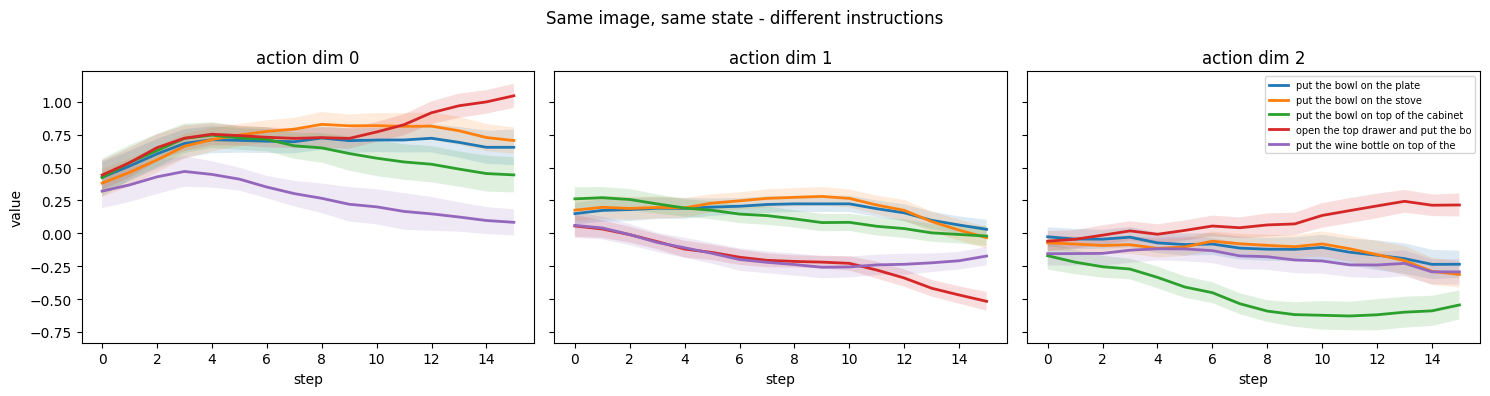

In [5]:
import matplotlib.pyplot as plt

@torch.no_grad()
def sample(c, n=64):
    """Draw n action chunks from the policy for a single conditioning vector."""
    c = c.repeat(n,1).to(dev)
    xt = torch.randn(n, OUT, device=dev)
    for k in reversed(range(NT)):                          # DDPM reverse process
        kk = torch.full((n,1), float(k), device=dev)
        e = eps(xt, kk, c)
        xt = (xt - beta[k]/(1-ab[k]).sqrt()*e)/alpha[k].sqrt()
        if k > 0: xt = xt + beta[k].sqrt()*torch.randn_like(xt)
    return (xt.cpu()*ysd + ymu).reshape(n, H, 7)

# an early frame from a "put the bowl on the plate" episode (task 0)
sel = np.where((ti_s[idx_c] == 0) & (fi_s[idx_c] < 5))[0][0]
img0, st0 = IMG[sel:sel+1], STA[sel:sel+1]

# bowl->plate, bowl->stove, bowl->cabinet, drawer+bowl, wine->cabinet
PROBE = [0, 7, 8, 2, 4]

res = {}
for t in PROBE:
    c = (torch.cat([img0, TXT[t:t+1], st0], -1) - cmu)/csd
    res[t] = sample(c)                                     # (64, 16, 7)

means  = torch.stack([res[t].mean(0) for t in PROBE])      # (K, 16, 7)
within = torch.stack([res[t].std(0).mean() for t in PROBE]).mean()
K = len(PROBE)
between = torch.stack([(means[a]-means[b]).abs().mean()
                       for a in range(K) for b in range(a+1, K)]).mean()
print(f"divergence BETWEEN instructions : {between:.4f}")
print(f"dispersion WITHIN an instruction: {within:.4f}")
print(f"RATIO                           : {between/within:.2f}   (>1 = language controls)")

fig, ax = plt.subplots(1, 3, figsize=(15,4), sharey=True)
for dim, a in zip([0,1,2], ax):
    for t in PROBE:
        m = res[t].mean(0)[:,dim]; s = res[t].std(0)[:,dim]
        a.plot(m, lw=2, label=TASKS[t][:34])
        a.fill_between(range(H), m-s, m+s, alpha=.15)
    a.set_title(f"action dim {dim}"); a.set_xlabel("step")
ax[0].set_ylabel("value"); ax[2].legend(fontsize=7)
plt.suptitle("Same image, same state - different instructions")
plt.tight_layout(); plt.savefig("/kaggle/working/E1_language_control.png", dpi=150)
plt.show()

### Averaged over many states

One state is an anecdote; 20 states with error bars is a measurement.

In [6]:
ratios  = []
sel_all = np.where(fi_s[idx_c] < 10)[0]        # early frames, where the scene is ambiguous
rng = np.random.default_rng(0)

for s in rng.choice(sel_all, 20, replace=False):
    i0, s0 = IMG[s:s+1], STA[s:s+1]
    r = {t: sample(torch.cat([i0, TXT[t:t+1], s0], -1).sub(cmu).div(csd), n=32)
         for t in PROBE}
    m = torch.stack([r[t].mean(0) for t in PROBE])
    w = torch.stack([r[t].std(0).mean() for t in PROBE]).mean()
    K = len(PROBE)
    b = torch.stack([(m[a]-m[c]).abs().mean()
                     for a in range(K) for c in range(a+1, K)]).mean()
    ratios.append((b/w).item())

ratios = np.array(ratios)
print(f"mean ratio: {ratios.mean():.2f} +/- {ratios.std():.2f}  (n=20 states)")

mean ratio: 2.70 +/- 0.30  (n=20 states)


### Negative control: paraphrases

Three phrasings of the *same* goal. If the policy responds to meaning rather than to
surface form, these should differ no more than sampling noise.

In [7]:
PARA = {
 0: ["put the bowl on the plate",
     "place the bowl onto the plate",
     "set the bowl down on the plate"],
 6: ["turn on the stove",
     "switch on the stove",
     "start the stove"],
 9: ["open the middle drawer of the cabinet",
     "pull open the cabinet's middle drawer",
     "open the cabinet middle drawer"],
}

rows = []
for t, variants in PARA.items():
    E = embed_text(variants)                               # (3, 384)
    rr = []
    for s in rng.choice(sel_all, 10, replace=False):
        i0, s0 = IMG[s:s+1], STA[s:s+1]
        r = [sample(torch.cat([i0, E[k:k+1], s0], -1).sub(cmu).div(csd), n=32)
             for k in range(len(variants))]
        m = torch.stack([x.mean(0) for x in r])
        w = torch.stack([x.std(0).mean() for x in r]).mean()
        K = len(variants)
        b = torch.stack([(m[a]-m[c]).abs().mean()
                         for a in range(K) for c in range(a+1, K)]).mean()
        rr.append((b/w).item())
    rows.append((TASKS[t][:34], np.mean(rr), np.std(rr)))

print(f"{'task':36s} paraphrase ratio")
for n_, mu, sd in rows: print(f"{n_:36s} {mu:.2f} +/- {sd:.2f}")
print(f"\n{'--- reference: DIFFERENT instructions':36s} {ratios.mean():.2f} +/- {ratios.std():.2f}")

task                                 paraphrase ratio
put the bowl on the plate            1.14 +/- 0.16
turn on the stove                    1.79 +/- 0.14
open the middle drawer of the cabi   0.68 +/- 0.13

--- reference: DIFFERENT instructions 2.70 +/- 0.30


## 4. E2 — does the policy notice when its inputs degrade?

Raw pixels are needed here, so a small evaluation set is streamed separately.

**Limitation (stated up front):** these frames overlap with the training frames.
This is acceptable for measuring the *relative* change in error as degradation
increases, but it is not a generalisation measurement.

In [8]:
N_EVAL = 2000

ds2 = load_dataset(REPO, split="train", streaming=True)
raw, est, eac, eti, eei, efi = [], [], [], [], [], []
for r in islice(iter(ds2), N_EVAL):
    raw.append(torch.from_numpy(np.array(r["observation.images.image"].convert("RGB"))))
    est.append(r["observation.state"]); eac.append(r["action"])
    eti.append(r["task_index"]); eei.append(r["episode_index"]); efi.append(r["frame_index"])

raw = torch.stack(raw)                                     # (N, 256, 256, 3) uint8
est = torch.tensor(np.array(est), dtype=torch.float32)
eac = torch.tensor(np.array(eac), dtype=torch.float32)
eti, eei, efi = map(np.array, (eti, eei, efi))
torch.save({"raw":raw, "st":est, "ac":eac, "ti":eti, "ei":eei, "fi":efi},
           "/kaggle/working/eval_raw.pt")
print(raw.shape, raw.dtype, "tasks:", np.unique(eti), flush=True)

Resolving data files:   0%|          | 0/66 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/66 [00:00<?, ?it/s]

torch.Size([2000, 256, 256, 3]) torch.uint8 tasks: [0 1 2 3 4 5 6 7]


In [9]:
import torch.nn.functional as F

# ---------- evaluation pairs ----------
o = np.lexsort((efi, eei))
r_s, s_s, a_s, t_s, e_s, f_s = raw[o], est[o], eac[o], eti[o], eei[o], efi[o]
ic, ich = [], []
for e in np.unique(e_s):
    m = np.where(e_s == e)[0]
    for j in range(len(m)-H): ic.append(m[j]); ich.append(m[j+1:j+1+H])
ic, ich = np.array(ic), np.array(ich)

SUB = np.random.default_rng(0).choice(len(ic), min(400, len(ic)), replace=False)
ic, ich = ic[SUB], ich[SUB]
TGT   = a_s[ich].reshape(len(ic), -1)
STA_e = s_s[ic]
TXT_e = TXT[t_s[ic]]
print("evaluation states:", len(ic), flush=True)

# ---------- visual degradations ----------
def degrade(x, kind, lvl):
    """x: (B, 3, H, W) float in [0,1]. lvl = 0 leaves the image untouched."""
    if lvl == 0: return x
    if kind == "blur":                                     # box blur, kernel 2*lvl+1
        k = int(lvl)*2+1
        g = torch.ones(3,1,k,k, device=x.device)/(k*k)
        return F.conv2d(F.pad(x, (k//2,)*4, mode="reflect"), g, groups=3)
    if kind == "occlusion":                                # grey square at the centre
        x = x.clone(); s = max(2, int(256*lvl))
        x[:, :, 128-s//2:128+s//2, 128-s//2:128+s//2] = 0.5
        return x
    if kind == "darkness":                                 # global dimming
        return (x*(1-lvl)).clamp(0,1)

evaluation states: 400


In [10]:
@torch.no_grad()
def embed_deg(kind, lvl, bs=128):
    """Re-embed the evaluation images through the frozen encoder after degradation."""
    out = []
    for i in range(0, len(ic), bs):
        idx = ic[i:i+bs]
        x = r_s[idx].permute(0,3,1,2).float().to(dev)/255.
        out.append(rn(norm(degrade(x, kind, lvl))).cpu())
    return torch.cat(out)

@torch.no_grad()
def predict(img_emb, n=8):
    """Return (MAE against ground-truth chunks, mean dispersion across n samples)."""
    c = torch.cat([img_emb, TXT_e, STA_e], -1)
    c = ((c-cmu)/csd).to(dev).repeat_interleave(n, 0)
    xt = torch.randn(len(c), OUT, device=dev)
    for k in reversed(range(NT)):
        kk = torch.full((len(c),1), float(k), device=dev)
        e = eps(xt, kk, c)
        xt = (xt - beta[k]/(1-ab[k]).sqrt()*e)/alpha[k].sqrt()
        if k > 0: xt = xt + beta[k].sqrt()*torch.randn_like(xt)
    p = (xt.cpu()*ysd + ymu).reshape(-1, n, OUT)
    return (p.mean(1)-TGT).abs().mean().item(), p.std(1).mean().item()

blur        level=0     MAE=0.0682  dispersion=0.0579
blur        level=2     MAE=0.2305  dispersion=0.0427
blur        level=4     MAE=0.3249  dispersion=0.0457
blur        level=8     MAE=0.4503  dispersion=0.0467
blur        level=16    MAE=0.4803  dispersion=0.0507
occlusion   level=0     MAE=0.0681  dispersion=0.0575
occlusion   level=0.2   MAE=0.1204  dispersion=0.0591
occlusion   level=0.4   MAE=0.2081  dispersion=0.0460
occlusion   level=0.6   MAE=0.2536  dispersion=0.0360
occlusion   level=0.8   MAE=0.2853  dispersion=0.0379
darkness    level=0     MAE=0.0681  dispersion=0.0576
darkness    level=0.25  MAE=0.0879  dispersion=0.0585
darkness    level=0.5   MAE=0.1281  dispersion=0.0589
darkness    level=0.75  MAE=0.2156  dispersion=0.0620
darkness    level=0.9   MAE=0.3171  dispersion=0.0674


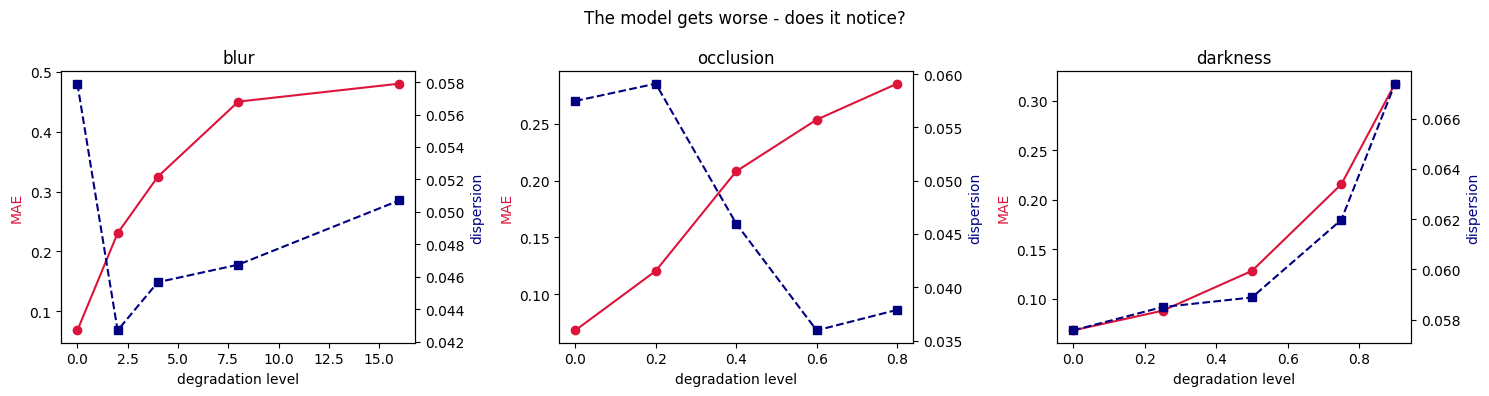

blur         corr(MAE, dispersion) = -0.436
occlusion    corr(MAE, dispersion) = -0.947
darkness     corr(MAE, dispersion) = 0.984


In [11]:
LEVELS = {"blur":      [0, 2, 4, 8, 16],
          "occlusion": [0, .2, .4, .6, .8],
          "darkness":  [0, .25, .5, .75, .9]}

out = {}
for kind, lv in LEVELS.items():
    out[kind] = []
    for l in lv:
        m, u = predict(embed_deg(kind, l))
        out[kind].append((l, m, u))
        print(f"{kind:11s} level={l:<5} MAE={m:.4f}  dispersion={u:.4f}", flush=True)

fig, ax = plt.subplots(1, 3, figsize=(15,4))
for a, (kind, vals) in zip(ax, out.items()):
    l, m, u = zip(*vals)
    a2 = a.twinx()
    a.plot(l, m, "o-", color="crimson"); a2.plot(l, u, "s--", color="navy")
    a.set_title(kind); a.set_xlabel("degradation level")
    a.set_ylabel("MAE", color="crimson"); a2.set_ylabel("dispersion", color="navy")
plt.suptitle("The model gets worse - does it notice?")
plt.tight_layout(); plt.savefig("/kaggle/working/E2_degradation.png", dpi=150); plt.show()

for kind, vals in out.items():
    l, m, u = map(np.array, zip(*vals))
    print(f"{kind:11s}  corr(MAE, dispersion) = {np.corrcoef(m,u)[0,1]:.3f}")

### Is the change in dispersion real?

The dispersion moves within a narrow band, so the measurement is repeated with
five seeds before drawing any conclusion from it.

In [12]:
for lvl in [0, 16]:
    vals = [predict(embed_deg("blur", lvl))[1] for _ in range(5)]
    print(f"blur {lvl}: dispersion = {np.mean(vals):.4f} +/- {np.std(vals):.4f}")

blur 0: dispersion = 0.0576 +/- 0.0003
blur 16: dispersion = 0.0506 +/- 0.0000


### Cross-modality control: a wrong instruction

Each state is given the *next* task's instruction: a well-formed sentence that is
semantically wrong for the scene. If dispersion is blind here too, the effect is
general rather than an artefact of the visual channel.

In [13]:
TXT_wrong = TXT[(t_s[ic]+1) % 10]

mae_ok, _ = predict(embed_deg("blur", 0))
TXT_save  = TXT_e
TXT_e     = TXT_wrong
mae_w, disp_w = predict(embed_deg("blur", 0))
TXT_e     = TXT_save

print(f"wrong instruction: MAE={mae_w:.4f}  dispersion={disp_w:.4f}   "
      f"(correct instruction: MAE={mae_ok:.4f})")

wrong instruction: MAE=0.2390  dispersion=0.0541   (correct instruction: MAE=0.0690)


## 5. Persist results

In [14]:
import json

results = {
  "setup": {
    "dataset": REPO, "training_frames": N_FRAMES, "training_pairs": int(len(idx_c)),
    "horizon": H, "diffusion_steps": NT,
    "vision_encoder": "ResNet18 (ImageNet, frozen)",
    "language_encoder": "all-MiniLM-L6-v2 (frozen)",
    "eval_frames": N_EVAL, "eval_states": int(len(ic)),
  },
  "E1_language_control": {
    "ratio_different_instructions": [float(ratios.mean()), float(ratios.std())],
    "ratio_paraphrase": {n_: [float(mu), float(sd)] for n_, mu, sd in rows},
  },
  "E2_degradation": {k: [[float(a) for a in v] for v in vals] for k, vals in out.items()},
}
json.dump(results, open("/kaggle/working/results.json", "w"), indent=2)
print(json.dumps(results, indent=2))

{
  "setup": {
    "dataset": "lerobot/libero_goal_image",
    "training_frames": 20000,
    "training_pairs": 17393,
    "horizon": 16,
    "diffusion_steps": 100,
    "vision_encoder": "ResNet18 (ImageNet, frozen)",
    "language_encoder": "all-MiniLM-L6-v2 (frozen)",
    "eval_frames": 2000,
    "eval_states": 400
  },
  "E1_language_control": {
    "ratio_different_instructions": [
      2.695356559753418,
      0.2952675785162581
    ],
    "ratio_paraphrase": {
      "put the bowl on the plate": [
        1.144234585762024,
        0.16227537590047486
      ],
      "turn on the stove": [
        1.793575119972229,
        0.14293182761624318
      ],
      "open the middle drawer of the cabi": [
        0.6812734335660935,
        0.13177052277271606
      ]
    }
  },
  "E2_degradation": {
    "blur": [
      [
        0.0,
        0.06817043572664261,
        0.057901524007320404
      ],
      [
        2.0,
        0.23049403727054596,
        0.042700059711933136
      ],
 